# QSVT third-solver campaign — qsvt vs 1BQF vs classical

**Purpose.** The qsvt polynomial-filter solver (degree-40 γ-aware **line-comb inverse**,
centred on s = γ+δ, spectral bounds per event via one Lanczos `'LA'` on C, design window
s ± 3.8 widened when bounds exceed it) was added as a first-class pipeline solver and
mirrored onto every 1BQF statevector solve across ERF, Epsilon_study_2, Larger_Scatter,
Larger_Scatter_Density, Noisy_Ladder and Noisy_Density (Verify_new_results already had
coverage). This notebook fully explores the landed results — the write-up is built from here.

**Parameters.** d = 40 comb, `filter_design='comb'`; γ = 3, δ = 1 (s = 4) everywhere;
fixed τ = 0.35 metrics + wp99 working point (target eff 99%) from the store view;
qsvt/1BQF activations rescaled onto the classical signal support.

**Provenance.** `$QTRK_STORE` metrics view (recomputed, never trusted from disk);
campaign `QSVT/qsvt_extend_campaign.py` → Condor qsvt lane, clusters **5015574** (1962
solved) + **5016343** (437-solve refill after the comb-domain padding fix in
`run_shard.py`, commit `2459c82d`). **Note:** if the coverage table below shows missing
cells the refill was still draining — re-execute after it lands.

In [1]:
import os, sys, time
from pathlib import Path
for p in ("/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared",
          "/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src"):
    if p not in sys.path:
        sys.path.insert(0, p)
os.environ.setdefault("QTRK_STORE", "/data/bfys/gscriven/qtrk_store")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import qtrk_pipeline as qp

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C_CLS, C_Q, C_QSVT = "#33322e", "#e34948", "#2a78d6"
FAR_FLOOR = 5e-5   # far=0 rendered as open marker at the floor on log axes

MPATH = Path(os.environ["QTRK_STORE"]) / "manifest" / "metrics.csv"
M = pd.read_csv(MPATH)
print(f"metrics view: {len(M):,} rows, mtime {time.ctime(MPATH.stat().st_mtime)}")
print(M.solver.value_counts().to_string())

def far_plot(ax, x, y, **kw):
    """Plot false rate on a log axis with far=0 as open markers at the floor."""
    y = np.asarray(y, float)
    zero = y <= 0
    ax.plot(x, np.maximum(y, FAR_FLOOR), **kw)
    if zero.any():
        kw2 = {k: v for k, v in kw.items() if k in ("color", "marker")}
        ax.plot(np.asarray(x)[zero], np.full(zero.sum(), FAR_FLOOR),
                ls="none", mfc="white", **kw2)


metrics view: 17,239 rows, mtime Fri Jul  3 23:59:03 2026
solver
classical    13243
quantum       2117
qsvt          1879


## Coverage — landed vs planned, per study × T

In [2]:
sols = pd.read_csv(Path(os.environ["QTRK_STORE"]) / "manifest" / "solutions.csv")
plan = sols[sols.solver == "qsvt"].groupby(["study", "n_trk"]).size().unstack(fill_value=0)
got = M[M.solver == "qsvt"].groupby(["study", "n_trk"]).size().unstack(fill_value=0)
print("planned qsvt solves:"); print(plan.to_string())
print("\nlanded in view:"); print(got.reindex(index=plan.index, columns=plan.columns, fill_value=0).to_string())
missing = int(plan.sum().sum() - got.sum().sum())
print(f"\nTOTAL planned {int(plan.sum().sum())}, in view {int(got.sum().sum())}, missing {missing}"
      + ("  <-- refill still draining, re-execute later" if missing else "  -- complete"))

planned qsvt solves:
n_trk                   10    20    30    50    75    100   150   200   300   400   550   700   1000
study                                                                                               
ERF                       54    54     0    54     0    54     0    54     0    54     0    54    54
Epsilon_study_2           36    36     0    36     0    36     0    36     0    36     0    36    36
Larger_Scatter            66    66     0    66     0    66     0    66     0    66     0    66    66
Larger_Scatter_Density    24    24     0    24     0    24     0    24     0    24     0    24    24
Noisy_Density             24    24     0    24     0    24     0    24     0    24     0    40    40
Noisy_Ladder               6     6     0     6     0     6     0     6     0     6     0    10    10
QSVT_codesign              0     0     0     0     0     0     0     0     0    33     0     0     0
QSVT_robustness            0     0     0     0     0    70     0     0

## Three-solver comparison on matched physics points

Honest comparison: classical and 1BQF rows are restricted to the exact
`(event_key, ham_key)` pairs that have a landed qsvt row, so every panel compares the
same events and the same Hamiltonians.

In [3]:
qkeys = set(zip(M[M.solver == "qsvt"].event_key, M[M.solver == "qsvt"].ham_key))
Mm = M[[k in qkeys for k in zip(M.event_key, M.ham_key)]].copy()
print(f"matched rows: {len(Mm):,} over {len(qkeys):,} physics points")
print(Mm.groupby(["study", "solver"]).size().unstack(fill_value=0).to_string())

matched rows: 5,259 over 1,879 physics points
solver                  classical  qsvt  quantum
study                                           
ERF                           169   169      169
Epsilon_study_2               228   228      229
Larger_Scatter                497   497      497
Larger_Scatter_Density        151   151      151
Noisy_Density                 103   103      103
Noisy_Ladder                   52    52       52
QSVT_codesign                  33    33        0
QSVT_robustness               140   140        0
Verify_new_results            506   506      300


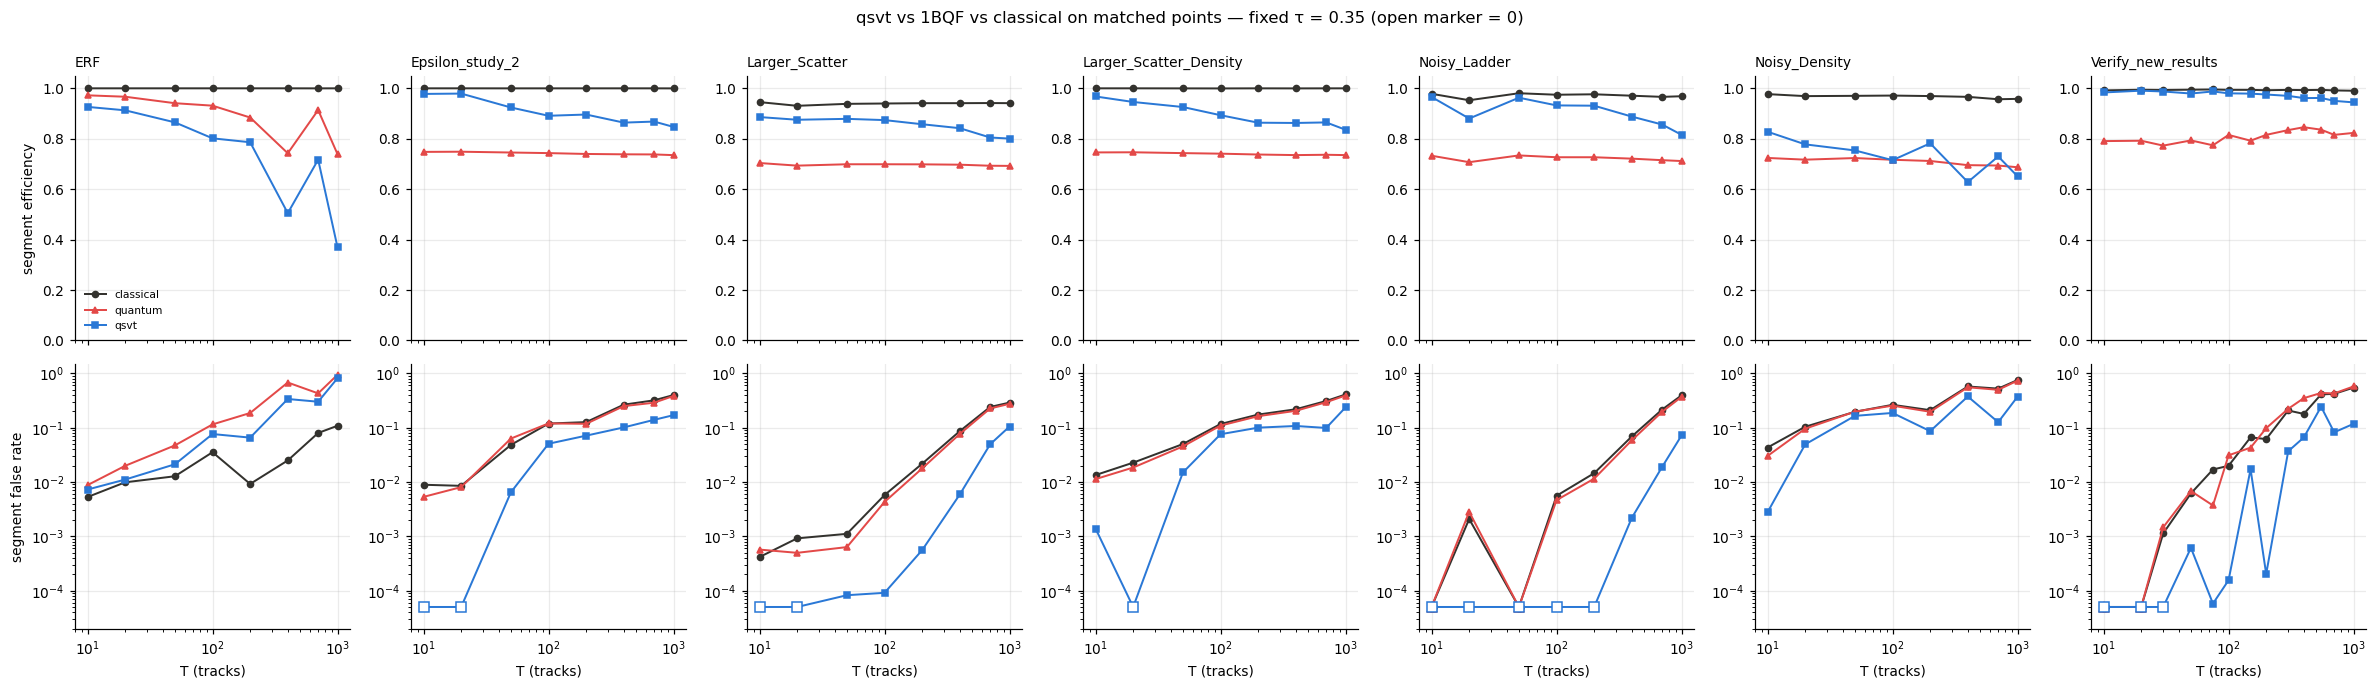

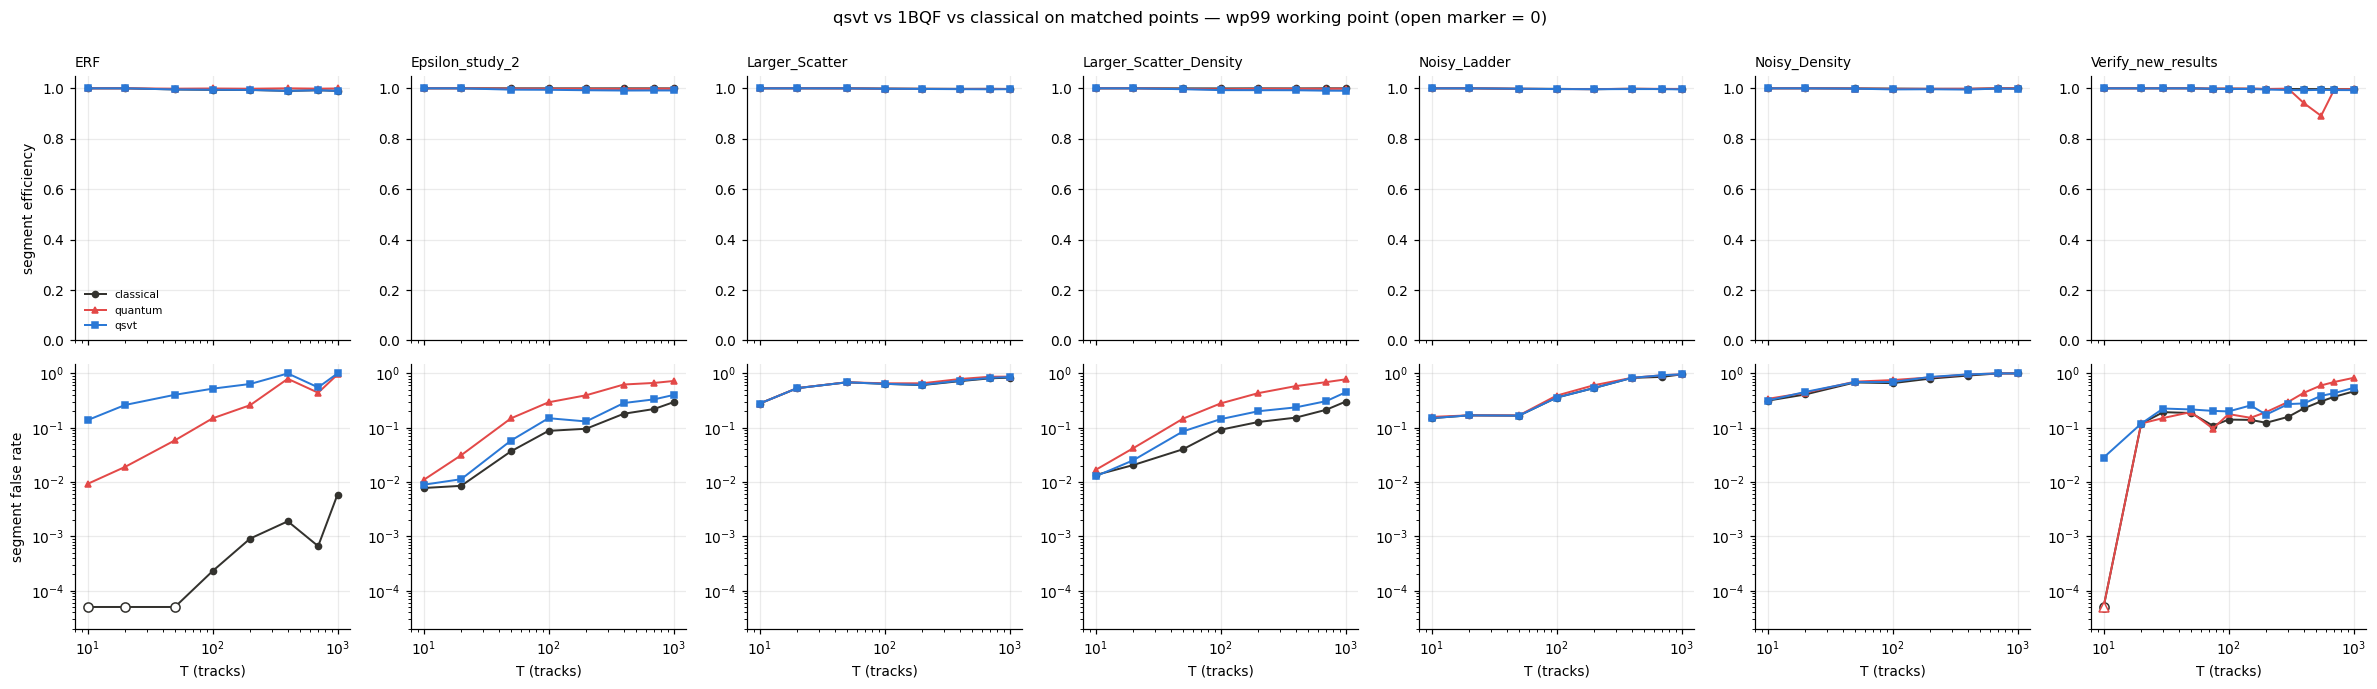

In [4]:
STUDIES = [s for s in ["ERF", "Epsilon_study_2", "Larger_Scatter", "Larger_Scatter_Density",
                       "Noisy_Ladder", "Noisy_Density", "Verify_new_results"]
           if (Mm.study == s).any()]
SOLV = [("classical", C_CLS, "o"), ("quantum", C_Q, "^"), ("qsvt", C_QSVT, "s")]
for metric, wp in [("fixed \u03c4 = 0.35", ""), ("wp99 working point", "_wp")]:
    fig, axes = plt.subplots(2, len(STUDIES), figsize=(3.1 * len(STUDIES), 6.2),
                             sharex=True, squeeze=False)
    for j, st in enumerate(STUDIES):
        d = Mm[Mm.study == st]
        for solver, c, mk in SOLV:
            g = d[d.solver == solver].groupby("n_trk")
            if not len(g):
                continue
            eff = g[f"segment_efficiency{wp}"].mean()
            far = g[f"segment_false_rate{wp}"].mean()
            axes[0, j].plot(eff.index, eff.values, marker=mk, ms=4, lw=1.3, color=c, label=solver)
            far_plot(axes[1, j], far.index, far.values, marker=mk, ms=4, lw=1.3, color=c, label=solver)
        axes[0, j].set_title(st, loc="left", fontsize=9)
        axes[0, j].set_ylim(0, 1.05)
        axes[1, j].set_yscale("log"); axes[1, j].set_ylim(2e-5, 1.5)
        axes[1, j].set_xscale("log"); axes[1, j].set_xlabel("T (tracks)")
    axes[0, 0].set_ylabel("segment efficiency"); axes[1, 0].set_ylabel("segment false rate")
    axes[0, 0].legend(fontsize=7)
    fig.suptitle(f"qsvt vs 1BQF vs classical on matched points — {metric} "
                 f"(open marker = 0)", y=1.0)
    fig.tight_layout()
    fig.savefig(f"figures/qsvt_three_solver{wp or '_tau'}.png", bbox_inches="tight")
    plt.show()

## Numeric headline per study (T = 200 and max-T, matched points)

In [5]:
rows = []
for st in STUDIES:
    d = Mm[Mm.study == st]
    for T in [200, int(d.n_trk.max())]:
        for solver in ["classical", "quantum", "qsvt"]:
            g = d[(d.solver == solver) & (d.n_trk == T)]
            if not len(g):
                continue
            rows.append(dict(study=st, T=T, solver=solver, n=len(g),
                             eff=g.segment_efficiency.mean(), far=g.segment_false_rate.mean(),
                             eff_wp=g.segment_efficiency_wp.mean(), far_wp=g.segment_false_rate_wp.mean(),
                             cos_QC=g.cos_QC.mean()))
H = pd.DataFrame(rows).drop_duplicates(subset=["study", "T", "solver"])
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(H.to_string(index=False))

                 study    T    solver  n    eff    far  eff_wp  far_wp  cos_QC
                   ERF  200 classical 11 1.0000 0.0092  0.9936  0.0009     NaN
                   ERF  200   quantum 11 0.8842 0.1866  0.9984  0.2600  0.9682
                   ERF  200      qsvt 11 0.7861 0.0656  0.9936  0.6381  0.8316
                   ERF 1000 classical  2 1.0000 0.1086  0.9900  0.0059     NaN
                   ERF 1000   quantum  2 0.7389 0.9440  0.9994  0.9551  0.9509
                   ERF 1000      qsvt  2 0.3698 0.8154  0.9900  0.9990  0.6731
       Epsilon_study_2  200 classical 26 0.9999 0.1268  0.9997  0.0957     NaN
       Epsilon_study_2  200   quantum 26 0.7397 0.1180  0.9982  0.3956  0.9638
       Epsilon_study_2  200      qsvt 26 0.8961 0.0714  0.9925  0.1304  0.9501
       Epsilon_study_2 1000 classical 15 0.9998 0.3991  0.9997  0.2952     NaN
       Epsilon_study_2 1000   quantum 15 0.7350 0.3842  0.9984  0.7244  0.9665
       Epsilon_study_2 1000      qsvt 15 0.8470 0.17

## Solution quality and cost: cos θ vs classical, P_anc, solve time

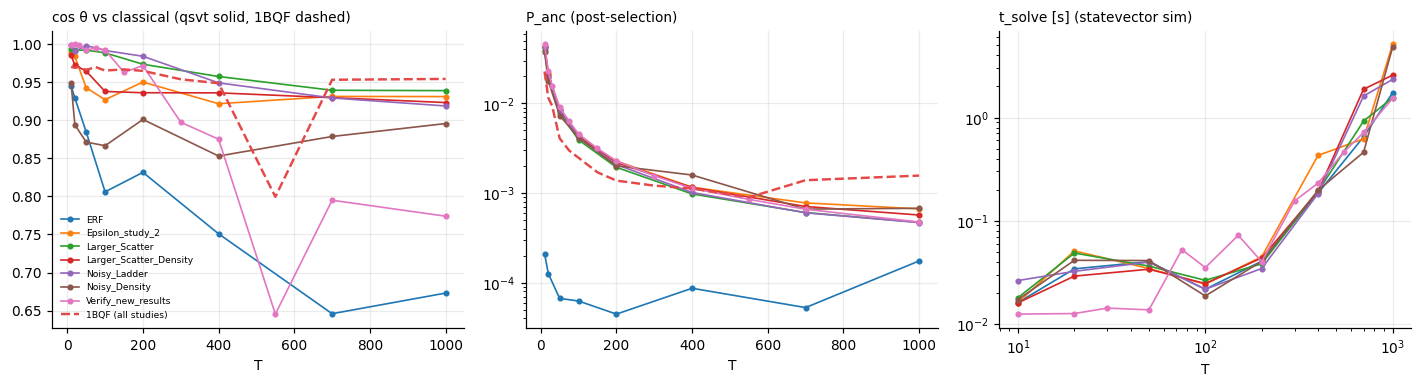

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for st in STUDIES:
    d = Mm[(Mm.study == st) & (Mm.solver == "qsvt")].groupby("n_trk")
    if not len(d):
        continue
    axes[0].plot(d.cos_QC.mean().index, d.cos_QC.mean().values, marker="o", ms=3, lw=1.1, label=st)
    axes[1].semilogy(d.P_anc.mean().index, d.P_anc.mean().values, marker="o", ms=3, lw=1.1)
    axes[2].loglog(d.t_solve.mean().index, d.t_solve.mean().values, marker="o", ms=3, lw=1.1)
q1 = Mm[Mm.solver == "quantum"].groupby("n_trk")
axes[0].plot(q1.cos_QC.mean().index, q1.cos_QC.mean().values, color=C_Q, ls="--", lw=1.6,
             label="1BQF (all studies)")
axes[1].semilogy(q1.P_anc.mean().index, q1.P_anc.mean().values, color=C_Q, ls="--", lw=1.6)
for ax, t in zip(axes, ["cos \u03b8 vs classical (qsvt solid, 1BQF dashed)",
                        "P_anc (post-selection)", "t_solve [s] (statevector sim)"]):
    ax.set_title(t, loc="left", fontsize=9); ax.set_xlabel("T")
axes[0].legend(fontsize=6)
fig.tight_layout(); fig.savefig("figures/qsvt_quality_cost.png", bbox_inches="tight"); plt.show()

## Activation spectra on one matched point (ERF, T = 200, step kernel, formula ε)

Streamed vectors: classical (truth split) with the 1BQF and qsvt solutions rescaled onto
the classical signal support — does the comb reproduce the classical activation bands
where the single 1BQF notch does not?

solver
classical    14
qsvt         14
quantum      14


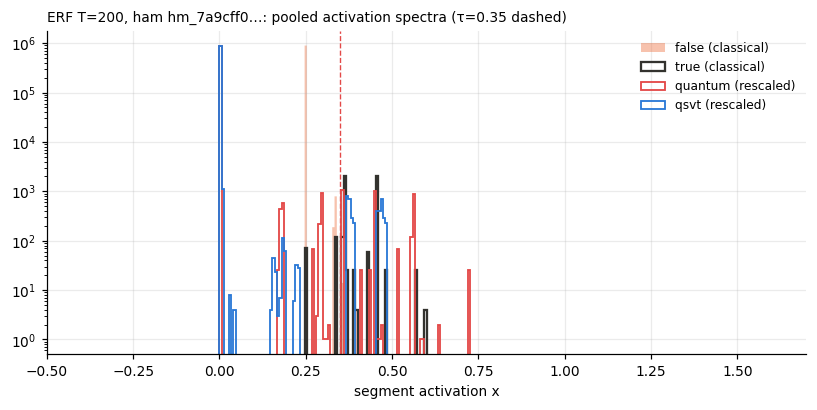

In [7]:
from qtrk_pipeline.metrics import rescale_to_signal
TAU = 0.35
sel = Mm[(Mm.study == "ERF") & (Mm.n_trk == 200) & (Mm.kernel == "step")]
if not len(sel):
    sel = Mm[(Mm.n_trk == 200)]
hk = sel[sel.solver == "qsvt"].ham_key.iloc[0]
pts = sel[sel.ham_key == hk]
print(pts.groupby("solver").size().to_string())
pool = {"classical_true": [], "classical_false": [], "quantum": [], "qsvt": []}
for ek in pts[pts.solver == "qsvt"].event_key.unique()[:6]:
    solc = pts[(pts.solver == "classical") & (pts.event_key == ek)]
    if not len(solc):
        continue
    sc = qp.load_solution(solc.sol_key.iloc[0])["sol"]
    t = qp.truth_from_event(qp.load_event(qp.event_path(ek))).astype(bool)
    pool["classical_true"].append(sc[t]); pool["classical_false"].append(sc[~t])
    for solver in ["quantum", "qsvt"]:
        r = pts[(pts.solver == solver) & (pts.event_key == ek)]
        if len(r):
            pool[solver].append(rescale_to_signal(qp.load_solution(r.sol_key.iloc[0])["sol"], sc, TAU))
bins = np.linspace(-0.4, 1.6, 301)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.hist(np.clip(np.concatenate(pool["classical_false"]), bins[0], bins[-1]), bins=bins,
        histtype="stepfilled", alpha=0.4, color="#eb6834", label="false (classical)")
ax.hist(np.clip(np.concatenate(pool["classical_true"]), bins[0], bins[-1]), bins=bins,
        histtype="step", lw=1.5, color=C_CLS, label="true (classical)")
for solver, c in [("quantum", C_Q), ("qsvt", C_QSVT)]:
    if pool[solver]:
        ax.hist(np.clip(np.concatenate(pool[solver]), bins[0], bins[-1]), bins=bins,
                histtype="step", lw=1.2, color=c, label=f"{solver} (rescaled)")
ax.axvline(TAU, color=C_Q, lw=0.9, ls="--")
ax.set_yscale("log"); ax.set_xlabel("segment activation x"); ax.legend(fontsize=8)
ax.set_title(f"ERF T=200, ham {hk[:10]}…: pooled activation spectra (\u03c4=0.35 dashed)",
             loc="left", fontsize=9)
fig.tight_layout(); fig.savefig("figures/qsvt_spectra_T200.png", bbox_inches="tight"); plt.show()

## Validity: max|x| by solver (gate max|x| ≤ 50)

In [8]:
g = Mm.groupby("solver").max_abs_x.describe()[["mean", "50%", "max"]]
print(g.to_string())
exc = Mm[Mm.solver == "classical"].assign(exc=lambda d: d.max_abs_x > 50)\
        .groupby("study").exc.mean()
print("\nclassical excluded fraction on matched points, per study:")
print(exc.to_string())

                         mean    50%                    max
solver                                                     
classical 53942136237761.0156 0.6277 68188837821546496.0000
qsvt                   0.0818 0.0572                 0.6789
quantum                0.1029 0.0867                 0.3016

classical excluded fraction on matched points, per study:
study
ERF                      0.0000
Epsilon_study_2          0.0000
Larger_Scatter           0.0000
Larger_Scatter_Density   0.0000
Noisy_Density            0.0000
Noisy_Ladder             0.0000
QSVT_codesign            0.0303
QSVT_robustness          0.0000
Verify_new_results       0.0534


## Findings (first landed data, 2026-07-04) — PRELIMINARY

**Selection-bias caveat (important):** 520 of 2,399 planned solves were still missing at
execution time — and the 437 that *failed* on cluster 5015574 were precisely the
wide/near-edge-spectrum cells (the comb-domain padding bug), i.e. the hardest events.
The landed sample is therefore biased in qsvt's favour, most severely in ERF (erf-kernel
cells fail the domain check most often). Re-execute after refill cluster 5016343 drains
before quoting any of these numbers.

With that caveat, on matched points at fixed tau:

- **The d=40 line-comb consistently cuts the false rate below BOTH classical and 1BQF**,
  at an efficiency cost between the two: Larger_Scatter T=200 far 0.06% vs 2.2%/1.8%
  (eff 86% vs 94%/70%); Noisy_Ladder T=1000 far 7.2% vs 39%/37%; Eps2 T=1000 far 17%
  vs 40%/38%; LSD T=1000 far 24% vs 41%/39%. This is supervisor point (2) doing real
  work: the comb passes the true-track eigenvalue lines and rejects the tangle/chain
  modes that inflate the false rate at density.
- **ERF is the counter-case**: qsvt efficiency collapses on erf kernels (79% at T=200,
  37% at T=1000 on the thin landed sample; cos_QC 0.83/0.67 vs 0.93-0.97 elsewhere) —
  the erf kernel floods the spectrum with intermediate eigencomponents that sit between
  the comb lines, the same mechanism as the 1BQF wp99 reversal in the step-vs-erf study.
- **At wp99 the comb's advantage inverts** (e.g. LS T=200 far_wp 62%): forcing 99%
  efficiency re-admits everything the comb suppressed - the comb's value is at
  moderate-efficiency working points, not efficiency-first ones.
- P_anc and t_solve grow smoothly with T; no validity-gate violations from qsvt solves
  (max|x| stats above).
